# 이상치 (outlier)

- 단변량 이상치 : 평균적인 값에서 너무 멀리 떨어져 있는 겨웅 
- 다변량 이상치 : 여러 특징을 함께 봐서 찾는 것 


2. 이상치를 발견하는 방법들 😇
이상치를 어떻게 찾아낼 수 있을까요? 여러 가지 방법이 있지만, 여기서는 네 가지 주요 기법을 통해 이상치를 발견하는 방법을 자세히 살펴보겠습니다.

✅ 단변량 이상치 탐지(스테이지2):
1. Z-Score (Z-점수) Z-Score는 데이터에서 표준 편차를 활용해 이상치를 감지하는 간단하면서도 강력한 방법입니다. 이 방법은 데이터를 표준화하고, 각 데이터 포인트가 평균으로부터 얼마나 떨어져 있는지를 계산하여 이상치를 식별합니다. 특히 표준화된 데이터 세트에 효과적입니다.

2. IQR (Interquartile Range, 사분범위) IQR은 데이터의 중앙값을 기준으로 하여 '정상 범위'를 벗어나는 데이터 포인트를 찾아냅니다. Q1(제1사분위수)과 Q3(제3사분위수)를 계산하고, 이를 기반으로 IQR을 구한 후, IQR을 이용하여 이상치를 탐지합니다.

✅ 다변량 이상치 탐지(스테이지3):
3. DBSCAN (Density-Based Spatial Clustering of Applications with Noise) DBSCAN은 데이터 포인트들을 그룹화해서 이상치를 식별하는데 사용되는 클러스터링 알고리즘입니다. 데이터 포인트의 밀도를 기반으로 하며, 주변 데이터 포인트와의 관계를 고려하여 이상치를 찾아냅니다. 이 방법은 다양한 데이터 구조에서 유용합니다.

4. LOF (Local Outlier Factor) LOF는 데이터 포인트의 '지역적 밀도'를 측정하고, 이를 주변 포인트의 밀도와 비교하여 이상치를 탐지합니다. 주변 데이터 포인트와의 밀도 비율을 계산함으로써 이상치를 식별하며, 이 방법은 데이터의 지역적 밀도가 다를 때 효과적입니다.

이상치 탐지는 데이터 분석의 핵심 부분이며, 위에서 설명한 기법들은 다양한 데이터셋과 상황에 적용할 수 있습니다. 이러한 방법들을 이용하여 데이터에 숨어 있는 이상치를 효과적으로 식별할 수 있습니다.

# Z-점수(Z-score) 공식
데이터가 평균으로부터 표준편차의 몇 배만큼 떨어져 있는지를 나타내는 표준화 지수인 Z-점수의 계산 공식입니다. 

## 예시 파일
10.1.Outlier.ipynb

## 답변
Z-점수(Z-score)를 구하는 수학 공식은 다음과 같습니다.

$$ Z = \frac{x - \mu}{\sigma} $$

- $x$ : 개별 데이터 값
- $\mu$ : 전체 데이터의 평균 (Mean)
- $\sigma$ : 전체 데이터의 표준편차 (Standard Deviation)

**초보자를 위한 쉬운 설명:**
내 데이터($x$)에서 평균($\mu$)을 빼서 "평균과의 차이"를 구한 다음, 그 차이가 데이터들이 퍼져있는 정도인 표준편차($\sigma$)의 몇 배나 되는지를 구하는 식입니다. 
즉, **"이 데이터가 평균으로부터 얼마만큼 동떨어져 있는가?"**를 객관적인 통계 수치로 변환해 줍니다. 

일반적으로 이 Z-점수가 +3보다 크거나 -3보다 작은 경우(절대값이 3 이상인 경우), 중심에서 너무 멀리 떨어진 이례적인 값이기 때문에 **이상치(Outlier)**로 판단하곤 합니다.

### 추가 자료
- [위키백과 - 표준 점수(Z-score)](https://ko.wikipedia.org/wiki/%ED%91%9C%EC%A4%80_%EC%A0%90%EC%88%98)
- [Scikit-learn 공식 문서 (StandardScaler - Z-score 변환 라이브러리)](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

- Z-Score = 0: 데이터 포인트가 평균값에 정확히 일치합니다.
- Z-Score > 0: 데이터 포인트가 평균값보다 높습니다.
- Z-Score < 0: 데이터 포인트가 평균값보다 낮습니다.

Z-Score 직접 계산 후 이상치 제거: 이 방법에서는 데이터 세트의 평균과 표준편차를 사용하여 각 데이터 포인트의 Z-Score를 수동으로 계산합니다. 이후 설정한 Z-Score 임계값(예를 들어, ±2 또는 ±3)을 넘는 데이터 포인트를 이상치로 판단하고 제거할 수 있습니다.

Scipy를 이용한 Z-Score 계산과 이상치 제거: Scipy 라이브러리의 stats 모듈은 Z-Score 계산을 자동화하는 함수를 제공합니다. 이 함수를 사용하면 복잡한 계산 과정 없이도 쉽게 Z-Score를 계산할 수 있으며, 마찬가지로 설정한 임계값을 넘는 데이터 포인트를 식별하고 제거할 수 있습니다.



```python
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

train = pd.read_csv('train.csv')

X = train.drop('credit', axis=1)
y = train['credit']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

display(X_train.head(3))
display(X_train.shape)

plt.figure(figsize = (10,5))
sns.distplot(X_train['income_total'])
plt.show()

```

# z-score 계산 

```python
def out_zscore(data, threshold=3):
    mean = np.mean(data)
    std = np.std(data)
    zscores = [(x - mean) / std for x in data]
    outliers = [x for x in data if np.abs((x - mean) / std) > threshold]
    return zscores, len(outliers)

_, num_outliers = out_zscore(X_train.income_total)
print("Total number of outliers are", num_outliers)

zscores, _ = out_zscore(X_train.income_total)

plt.figure(figsize = (10,5))
sns.distplot(zscores)
plt.axvspan(xmin = 3 ,xmax= max(zscores),alpha=0.2, color='red')
#z-score가 3이상인 영역을 빨간색으로 강조, 수직 영역을 강조할 때 사용 alpha매개 변수는 영역의 투명도를 설정 

plt.show()
```

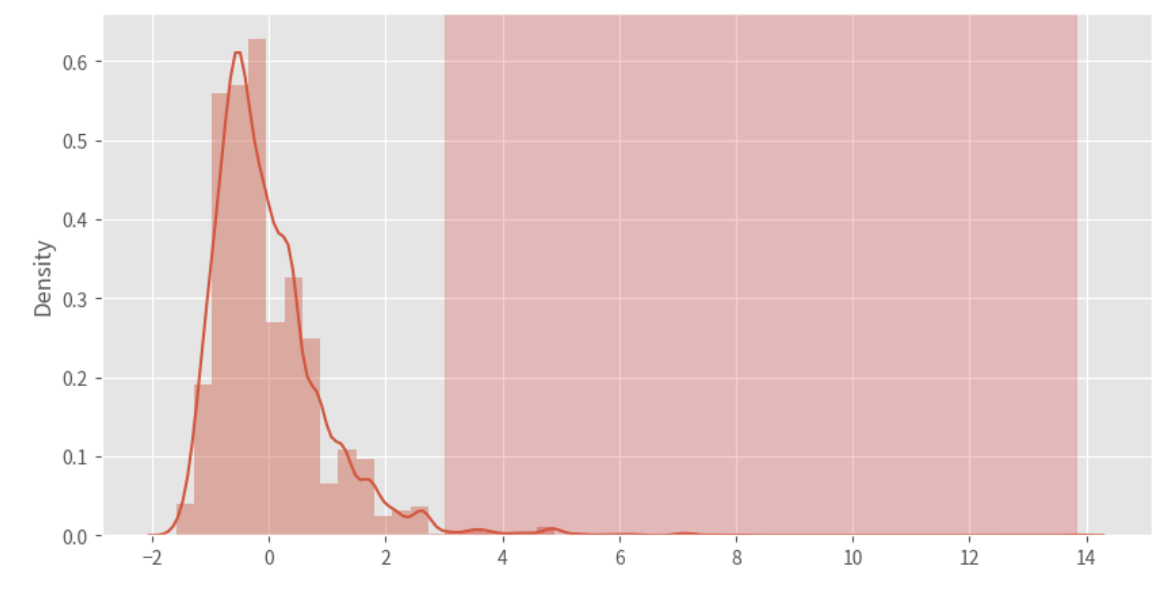

- 중심 분포 : 그래프의 중앙 부분은 z-score의 값이 -2에서 2사이에 집중, 비교적데이터 포인트가 평균에서 가까운 범위 내에 있음을 의미 
- 이상치 강조 : 이상치는 낮은 및도 
- 왼쪽 꼬리 : -3이하는 해당 범위에 이상치가 없거나 매우 적음을 의미 
- 오른쪽 꼬리 : 이상치가 존재 

## z-score 직접 계산 후 이상치 제거 

```python
Z_train = X_train.copy()

# Train 데이터의 평균, 표준편차 계산
mean_train = Z_train['income_total'].mean()
std_train = Z_train['income_total'].std()

# 임계값 설정
threshold = 3

# Train 데이터로 Z-점수 계산 및 이상치 제거
Z_train['z_score_income'] = (Z_train['income_total'] - mean_train) / std_train
train_no_outliers = Z_train[Z_train['z_score_income'].abs() <= threshold]

train_no_outliers = train_no_outliers.drop('z_score_income', axis=1)
train_no_outliers.shape
```

## Result 

```
(11050, 19)
```

# stats z-score 

```python
from scipy import stats

Z_scipy_train = X_train.copy()

# Train 데이터에 대해 Z-score 계산
Z_scipy_train['z_score_income'] = stats.zscore(Z_scipy_train['income_total'])

# 임계값 설정
threshold = 3

# 임계값을 기반으로 Train 데이터에서 이상치 제거
train_no_outliers = Z_scipy_train[Z_scipy_train['z_score_income'].abs() <= threshold]

# 임시 Z-score 컬럼 제거
train_no_outliers = train_no_outliers.drop('z_score_income', axis=1)
train_no_outliers.shape
```

## result 

```
(11050, 19)
```

## Z-Score 기법의 장점과 단점

### 장점 👍

- 간단하고 직관적
Z-Score는 평균과 표준편차를 이용한 간단한 계산으로 이루어져 있어, 구현하기 쉽고 결과 해석이 직관적입니다.

- 표준화된 점수
데이터 포인트가 데이터셋의 평균으로부터 얼마나 떨어져 있는지를 표준화된 형태로 표현하여, 서로 다른 데이터셋이나 변수 간 비교가 용이합니다.

- 정규 분포 데이터에 적합
데이터가 정규 분포를 따르는 경우, Z-Score는 이상치를 식별하는 데 매우 효과적입니다.

- 확장성
다양한 임계값 설정이 가능하며, 데이터의 특성에 맞게 조정할 수 있어 융통성이 뛰어납니다.

### 단점 👎

- 정규 분포 의존성
Z-Score 방법은 데이터가 정규 분포를 가정할 때 가장 잘 작동합니다. 데이터가 크게 비대칭적이거나 긴 꼬리를 가진 경우, 이상치 탐지에 오류가 발생할 수 있습니다.

- 극단값에 민감
극단적인 값이 포함된 경우, 이들 값이 평균과 표준편차에 큰 영향을 미칠 수 있으며, 이는 Z-Score 계산에 영향을 미칩니다.

- 모든 이상치를 식별하지 못할 수 있음
Z-Score는 간단한 통계적 접근 방식이기 때문에, 모든 유형의 이상치를 완벽히 식별하지 못할 수 있습니다. 특히, 데이터셋에 이상치가 많은 경우 효과적이지 않을 수 있습니다.

- 이진 결정의 어려움
어떤 데이터 포인트를 이상치로 간주할지에 대한 명확한 기준이 없기 때문에, 임계값 설정이 주관적일 수 있으며, 이에 따라 결과가 달라질 수 있습니다.

Z-Score를 이용한 이상치 제거 방법은 이러한 장단점을 고려하여 신중히 적용해야 하며, 경우에 따라 다른 이상치 탐지 방법과 병행하여 사용하는 것이 좋습니다. 데이터의 특성과 분석 목적에 따라 적절한 방법을 선택하는 것이 중요합니다.  



## IQR

### IQR을 이용한 이상치 탐지 실습

Quantile 함수를 활용하여 IQR 이상치 제거 : pandas 라이브러리의 quantile 함수를 사용하여 데이터 세트의 25번째 백분위수(Q1)와 75번째 백분위수(Q3)를 계산하고, 이를 통해 IQR을 구합니다.   
이상치는 Q1에서 1.5 * IQR을 뺀 값보다 작거나, Q3에 1.5 * IQR을 더한 값보다 큰 데이터 포인트로 정의됩니다. 이상치로 간주된 데이터 포인트들은 분석에서 제외하거나 추가 조사를 통해 처리될 수 있습니다.

Percentile 함수를 활용하여 IQR 이상치 제거: NumPy 라이브러리의 percentile 함수를 사용하여 동일한 백분위수를 계산합니다.  
이 함수는 전체 데이터 배열을 입력으로 받아, 지정된 백분위수에 해당하는 값을 반환합니다. 이후, quantile 함수와 유사하게 IQR을 구하고 이상치를 식별할 수 있습니다.

```python
plt.boxplot(X_train['income_total'], vert=False) 
plt.title('Boxplot for Feature income_total') 
plt.show() 

def out_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# 'income_total' 열의 이상치를 찾기 위한 조건
lower_bound, upper_bound = out_iqr(X_train['income_total'])

# 이상치를 각각의 조건으로 찾음
lower_outliers = X_train[X_train['income_total'] < lower_bound]
upper_outliers = X_train[X_train['income_total'] > upper_bound]

# 각각의 이상치 개수 계산
num_lower_outliers = len(lower_outliers)
num_upper_outliers = len(upper_outliers)

print("Number of lower outliers in 'income_total' column:", num_lower_outliers)
print("Number of upper outliers in 'income_total' column:", num_upper_outliers)
```

## Result

```
Number of lower outliers in 'income_total' column: 0
Number of upper outliers in 'income_total' column: 467
```

## quantile 함수를 활용하여 IQR 이상치 제거 

```python
lower_bound, upper_bound = out_iqr(X_train['income_total'])
train_no_outliers_iqr = X_train[(X_train['income_total'] >= lower_bound) & (X_train['income_total'] <= upper_bound)]

print("Shape of train data after removing outliers using IQR:", train_no_outliers_iqr.shape)
```

```
Shape of train data after removing outliers using IQR: (10734, 19)
```

## Percentile 함수를 활용하여 iqr 이상치 제거 

```python
Q1 = np.percentile(X_train['income_total'], 25)
Q3 = np.percentile(X_train['income_total'], 75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q1 + 1.5 * IQR

train_no_outliers_iqr_np = X_train[(X_train['income_total'] > lower_bound) & (X_train['income_total'] < upper_bound)]

print("Shape of train data after removing outliers using NumPy's percentile:", train_no_outliers_iqr.shape)
```

---

## Result 

```
Shape of train data after removing outliers using NumPy's percentile: (10734, 19)

```

## IQR을 활용한 이상치 탐지의 장점과 단점

### 장점 👍

- **강한 내성 (Robustness)**
  IQR은 데이터의 중앙 50% 영역에 초점을 맞추므로, 아주 극단적인 값(이상치)이 새롭게 추가되더라도 그 영향을 적게 받습니다. 데이터 분포가 비대칭적일 때 매우 유리합니다.

- **직관적인 이해**
  데이터를 4등분 하는 사분위수 개념에 기반하기 때문에, 계산 방식이나 "정상 범주"의 의미를 누구나 쉽게 그림(Boxplot 등)으로 이해할 수 있습니다.

- **비모수적 접근 (Non-parametric)**
  Z-score처럼 데이터가 꼭 정규 분포(종 모양)를 따라야 한다는 가정이 필요 없습니다. 분포 형태가 불규칙한 실무 데이터에서도 널리 쓰일 수 있습니다.

---

### 단점 👎

- **중요 정보 손실 위험**
  수식에 의해 기계적으로 제거된 이상치 안에, 사실은 문제 해결(예: 사기 거래 탐지, 암 진단 등)에 꼭 필요한 핵심 신호가 숨어 있었을 확률도 배제할 수 없습니다.

- **임계값의 임의성**
  일반적으로 $\text{Q1} - 1.5 \times \text{IQR}$ , $\text{Q3} + 1.5 \times \text{IQR}$ 을 기준으로 삼지만, 이 '$1.5$'라는 숫자는 절대적인 진리가 아닌 어느 정도 임의적인 설정입니다. 데이터 특성에 따라 3.0을 적용해야 하는 등 조율이 필요합니다.

> **💡 요약:** IQR은 극단값이 많은 데이터일수록 안전하고 훌륭한 이상치 탐지 기법입니다. 단, 무조건 제거하기보다는 제거 대상이 '진짜 버려도 되는 에러값'인지 꼭 한 번 확인하는 습관이 중요합니다.

데이터 변환: 이상치의 영향을 줄이기 위해 데이터를 변환할 수 있습니다. 데이터를 로그로 변환하거나, 제곱근을 취하거나, 역수를 취하는 등의 방법을 사용하여 데이터의 분포를 조절할 수 있습니다. 이렇게 하면 이상치의 영향을 줄일 수 있습니다.

이상치 점수화: 이상치를 제거하지 않고 데이터에서 이상치를 식별하고 점수화할 수 있습니다. 이 점수를 활용하여 모델링에 활용하거나, 이상치의 정도를 파악할 수 있습니다.

이상치 치환: 이상치를 다른 값으로 대체할 수 있습니다. 이상치를 해당 특성의 중앙값이나 평균값 등으로 대체하거나, 가장 가까운 정상치로 대체하는 방법을 사용할 수 있습니다.

모델 기반 접근: 일부 머신 러닝 모델은 이상치에 강건하며, 이상치를 자동으로 처리할 수 있습니다. 예를 들어, 랜덤 포레스트와 같은 트리 기반 모델은 이상치에 민감하지 않을 수 있습니다.

이상치를 고려한 모델링: 때로는 이상치가 중요한 정보를 제공하는 경우도 있습니다. 이런 경우, 이상치를 제거하지 않고 모델링을 수행하고, 결과에 미치는 영향을 조사하는 것이 유용할 수 있습니다.

# DBSCAN ( Density-based spatial clustering of applications with noise )

DBSCAN은 데이터 포인트들을 기반으로 클러스터를 형성하고, 이 과정에서 클러스터에 속하지 않는 포인트들을 이상치로 간주하는 클러스터링 알고리즘입니다.  
K-Means 알고리즘의 대안으로 사용되며, 미리 클러스터의 수를 정할 필요 없이 데이터 자체의 밀도에 기반하여 클러스터링을 수행합니다.  

1. 핵심 포인트 

- 주변 지역(eps 거리 내)에 일정 수(min_samples) 이상의 이웃 포인트가 있는 데이터 포인트 입니다.  
- 이 포인트들은 클러스터링 과정에서 클러스터의 핵심을 형성합니다. 

2. 경계 포인트 ( Border Points )

- 핵심 포인트의 이웃이지만, 그 자체로는 핵심 포인트의 조건(즉, min_samples 이상의 이웃)을 충족하지 않는 포인트 입니다.
- 이들은 클러스터의 경계를 형성합니다. 

3. 노이즈 포인트(Noise Points)

- 핵심 포인트나 경계 포인트가 아닌 모든 포인트, 어떤 클러스터에도 속하지 않는다. 
- 데이터 셋에서 이상치를 나타냄. 

# 핵심 작동 원리 

- DBSCAN(밀도 기반 공간 클러스터링)은 데이터의 공간에서 각 데이터 포인트 주변에 epsilon(엡실론) 반경의 원을 형성하고,   
이를 기반으로 데이터 포인트를 핵심(Core) 포인트, 경계(Border) 포인트, 노이즈(Noise) 포인트 로 분류합니다.  

- 이 때 고려해야 하는 두 가지 주요 매개변수는 epsilon(엡실론) 과 minPoints(최소 데이터 포인트 수) 입니다.  
epsilon은 각 데이터 포인트 주변에 형성되는 원의 반경으로, 데이터 포인트 간의 밀도를 정의하며,  
minPoints는 해당 원 내부에 존재해야 하는 최소 데이터 포인트 수로, 해당 데이터 포인트를 핵심 포인트로 분류하기 위한 조건입니다.  

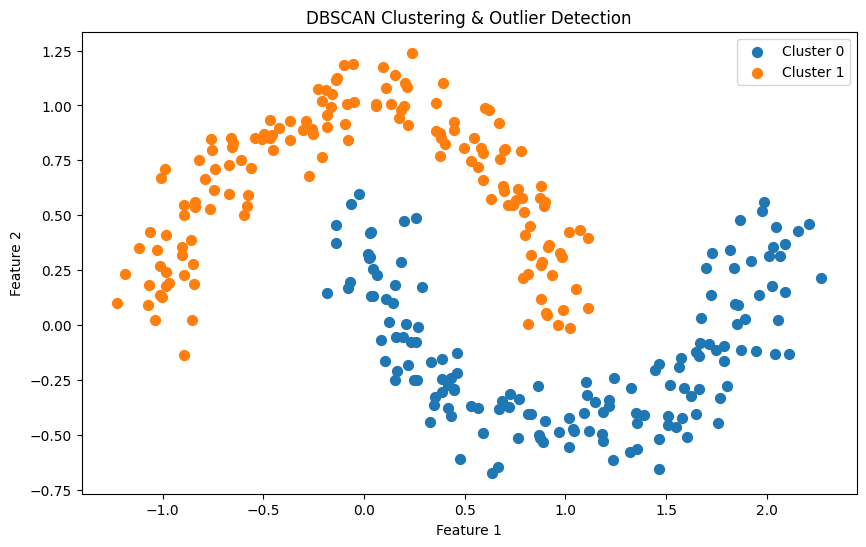

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# 1. 초승달 모양의 가상 데이터 생성 (약간의 노이즈 포함)
# K-Means로는 잘 묶이지 않는 복잡한 형태의 데이터입니다.
X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

# 2. DBSCAN 모델 생성 및 학습
# eps: 주변 이웃을 탐색할 반경 거리
# min_samples: 하나의 군집으로 인정받기 위해 탐색 반경 내에 필요한 최소 데이터 개수
dbscan = DBSCAN(eps=0.2, min_samples=5)
clusters = dbscan.fit_predict(X)

# 3. 시각화
plt.figure(figsize=(10, 6))

# 군집 라벨 확인 (노이즈는 '-1' 라벨을 가집니다)
unique_clusters = set(clusters)

for cluster in unique_clusters:
    if cluster == -1:
        # 노이즈(이상치)는 검은색 'x' 표시로 시각화
        cluster_data = X[clusters == cluster]
        plt.scatter(cluster_data[:, 0], cluster_data[:, 1], 
                    color='black', marker='x', s=60, label='Noise (Outlier)')
    else:
        # 정상적으로 묶인 군집 라벨들은 각각 다른 색의 점으로 표시
        cluster_data = X[clusters == cluster]
        plt.scatter(cluster_data[:, 0], cluster_data[:, 1], 
                    s=50, label=f'Cluster {cluster}')

plt.title('DBSCAN Clustering & Outlier Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## DBSCAN Example 

```python
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 데이터 준비
DBSCAN_train = X_train.copy()

numeric_columns = ['공복 혈당', '중성 지방']
data_numeric = DBSCAN_train[numeric_columns]

# 데이터 표준화
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_numeric)

# DBSCAN 클러스터링 (eps와 min_samples는 상황에 따라 조정 필요)
db = DBSCAN(eps=0.5, min_samples=5).fit(data_scaled) 
# eps 는 클러스터의 반경을 나타내고, min_samples는 클러스터를 형성하기 위한 최소 샘플 수 
labels = db.labels_

pd.Series(labels).value_counts()
```

---

## Result 

```
 0    4839
-1      42
 1      14
 2       5
dtype: int64
```

## 공복 혈당과 중성 지방 이상치 시각화 

```python
plt.figure(figsize=(10,6)) #가로 10인치 세로 6인치 

unique_labels = set(labels) # labels에서 고유값을 추출 0, 1, 2, ..., -1, ...
colors = ['blue', 'red']

for color, label in zip(colors, unique_labels): #colors와 unique_labels를 묶어서 반복문 실행 
    sample_mask = labels == label #sample mask boolean값 
    plt.plot(data_numeric.iloc[sample_mask, 0], data_numeric.iloc[sample_mask, 1], 'o', color=color)

# x축과 y축에 라벨 추가
plt.xlabel('공복 혈당', fontsize=10)
plt.ylabel('중성 지방', fontsize=10)

plt.title('공복 혈당과 중성 지방에 대한 DBSCAN 클러스터링', fontsize=10)
plt.grid(True) #그래프에 격자선을 추가하여 데이터를 더 쉽게 읽을 수 있도록 한다. 
plt.show()
```

```python

plt.figure(figsize=(10, 6))

# scatter: 2차원 공간에 점들을 흩뿌려 그리는 산점도(Scatter Plot) 함수
# x축 데이터: DBSCAN_train['공복 혈당']
# y축 데이터: DBSCAN_train['중성 지방']
# c: 점들의 색상을 지정하는 파라미터. 여기서는 군집 번호(clusters)별로 다른 색이 자동으로 부여됩니다.
# cmap='viridis': 색상을 다르게 칠할 때 사용할 색상 테마 패턴(Color Map)
plt.scatter(DBSCAN_train['공복 혈당'], DBSCAN_train['중성 지방'], c=DBSCAN_train['clusters'], cmap='viridis', label='Clusters')

# DBSCAN에서 -1 라벨은 노이즈(이상치)를 의미합니다. 이 노이즈들만 골라서 위에 빨간색 점으로 덧그려 눈에 잘 띄게 합니다.
plt.scatter(DBSCAN_train[DBSCAN_train['clusters'] == -1]['공복 혈당'], 
            DBSCAN_train[DBSCAN_train['clusters'] == -1]['중성 지방'], 
            color='red', label='Outliers')

plt.title('공복 혈당과 중성 지방의 scatter plot')
plt.xlabel('공복 혈당')
plt.ylabel('중성 지방')
plt.legend()
plt.grid(True)
plt.show()
```

## DBSCAN을 활용한 이상치 탐지의 장점과 단점

DBSCAN (Density-Based Spatial Clustering of Applications with Noise)은 이상치 탐지에 자주 사용되는 밀도 기반의 클러스터링 알고리즘입니다. 이 알고리즘은 특히 클러스터의 크기나 모양이 불규칙하거나 밀도가 다를 때 유용합니다. 이상치 탐지에 DBSCAN을 사용하는 것의 장점과 단점은 다음과 같습니다.

### 장점 👍

- **모델 형태에 대한 가정 불필요**  
  클러스터가 원형일 필요가 없으므로, 초승달 모양이든 띠 모양이든 불규칙한 모양의 군집도 아주 잘 찾아냅니다.

- **클러스터 개수 설정 불필요**  
  K-Means처럼 사전에 K(군집의 개수)를 사람이 정해줄 필요가 없습니다. 데이터의 밀도 분포를 보고 알고리즘이 스스로 군집의 개수를 결정합니다.

- **노이즈 및 이상치에 강건함**  
  밀도 조건(`eps` 반경 안에 `min_samples` 데이터 존재)을 충족하지 못하는 점들은 자연스럽게 '외톨이(노이즈)'로 분류되어 버려지므로(`-1`), 이상치 자체가 군집 형성에 악영향을 주거나 왜곡시키지 않습니다.

- **데이터 밀도에 따른 유연성**  
  `eps`(탐색 반경)와 `min_samples`(최소 기준 인원) 두 개의 파라미터를 조절하여, 데이터의 빽빡한 정도에 맞춰 유연하게 모델을 튜닝할 수 있습니다.

---

### 단점 👎

- **초기 파라미터 설정의 번거로움**  
  `eps`와 `min_samples` 값에 따라 결과가 천차만별로 달라집니다. 특히 최적의 `eps` 반경을 찾기 위해서 여러 차례 시도(Trial & Error)를 거쳐야 하는 편입니다.

- **변수 스케일(Scale) 변화에 극도로 민감**  
  점과 점 사이의 '거리'를 재기 때문에, 키, 몸무게, 가격 등 각 특성(Feature)의 단위가 다르면 제대로 된 밀도 측정이 불가능합니다. (반드시 표준화/정규화 등 데이터 스케일링 선행이 필수적입니다!)

- **고차원 데이터에서의 어려움 (차원의 저주)**  
  변수가 많아져 데이터가 고차원 공간에 뿌려지면 빈 공간이 너무 넓어져 데이터 간 거리가 모두 다 멀어지게 됩다. 이로 인해 밀도를 측정하기가 힘들어져 성능이 저하될 수 있습니다.

- **밀도 차이가 큰 복합 데이터에 취약**  
  어떤 쪽은 아주 촘촘하게 모여 있고, 다른 쪽은 아주 듬성듬성 퍼져 있다면, 듬성듬성한 곳은 통째로 노이즈로 쳐버리거나 촘촘한 곳은 통째로 한 군집으로 과하게 묶는 등 '하나의 고정된 eps'만으로는 커버하기 어렵습니다.

> **💡 요약:** DBSCAN은 K-Means로 해결하지 못하는 불규칙한 데이터의 군집화와 이상치(노이즈) 제거를 동시에 수행명령할 수 있는 탁월한 알고리즘입니다. 하지만 "모든 데이터의 스펙(Scale)이 동등하게 맞춰져 있어야 한다"는 전제 조건과 "고차원 데이터에서의 한계"를 명확히 인지하고 사용해야 합니다.

## LOF 

- LOF 알고리즘의 작동 원리
- 이웃 개수 설정: LOF 알고리즘을 시작하기 전에, 고려할 각 데이터 포인트의 이웃 수(n_neighbors)를 결정해야 합니다. 이웃의 수는 알고리즘이 얼마나 지역적으로 데이터를 보는지 결정합니다.  

- 지역 밀도 계산: 각 데이터 포인트의 지역 밀도를 계산합니다. 이것은 n_neighbors개의 가장 가까운 이웃까지의 거리를 기반으로 하며, 이웃들 사이의 평균 거리로 표현할 수 있습니다.  

- LOF 점수 계산: 각 데이터 포인트의 LOF 점수를 계산합니다. 이 점수는 데이터 포인트의 지역 밀도를 그 이웃들의 밀도와 비교함으로써 결정됩니다. LOF 점수가 1에 가까우면 데이터 포인트는 이웃들과 비슷한 밀도를 가지고 있다고 볼 수 있습니다. 점수가 1보다 많이 높으면 데이터 포인트는 이웃보다 밀도가 낮은 영역에 위치해 있으며, 이는 이상치일 가능성이 높음을 의미합니다.  

- 이상치 결정: LOF 점수가 특정 임곗값 이상인 데이터 포인트를 이상치로 분류합니다. 이 임곗값은 일반적으로 경험적으로 결정되거나, 특정 비율의 데이터 포인트가 이상치로 분류되도록 설정할 수 있습니다.  

- 이상치 제거: 이상치로 판정된 데이터 포인트를 데이터 세트에서 제거합니다.  

```python

from sklearn.neighbors import LocalOutlierFactor

# 데이터 준비
LOF_train = X_train.copy()
numeric_columns = ['공복 혈당', '중성 지방']
data_numeric = LOF_train[numeric_columns].values  

# Local Outlier Factor 모델 생성
clf = LocalOutlierFactor(n_neighbors=50, contamination='auto')

# 이상치 탐지
labels = clf.fit_predict(data_numeric)
pd.Series(labels).value_counts()

LOF_train['outliers_lof'] = labels

sample_no_outliers = LOF_train[LOF_train['outliers_lof'] != -1]

display(sample_no_outliers.head(3))
display(f"이상치가 아닌 데이터 포인트들의 수: {len(sample_no_outliers)}")

plt.figure(figsize=(10, 6))
plt.scatter(LOF_train['공복 혈당'], LOF_train['중성 지방'], c=LOF_train['outliers_lof'], cmap='viridis', label='Clusters')
plt.scatter(LOF_train[LOF_train['outliers_lof'] == -1]['공복 혈당'], 
            LOF_train[LOF_train['outliers_lof'] == -1]['중성 지방'], 
            color='red', label='Outliers')

plt.title('공복 혈당과 중성 지방의 scatter plot')
plt.xlabel('공복 혈당')
plt.ylabel('중성 지방')
plt.legend()
plt.grid(True)
plt.show()
```

LOF 를 활용한 이상치 탐지의 장점과 단점
장점 👍
지역적 밀도 차이 기반
LOF는 각 데이터 포인트의 지역적 밀도를 고려하여 이상치를 탐지합니다. 이 방법은 데이터셋의 전반적인 밀도 분포와 상관없이, 지역적 관점에서 이상치를 정확하게 식별할 수 있게 해줍니다.

다양한 데이터셋에 적용 가능
LOF는 다양한 형태와 밀도를 가진 데이터셋에 적용될 수 있으며, 특히 밀도가 불균일한 데이터셋에서 유용합니다.

이상치의 순위화
LOF는 단순히 이상치를 식별하는 것이 아니라, 이상치로 판단되는 정도를 점수로 제공합니다. 이를 통해 이상치들 사이에서도 상대적인 이상도를 평가할 수 있습니다.

파라미터 조정의 유연성
사용자는 이웃의 수(n_neighbors)와 같은 파라미터를 조정하여 알고리즘의 민감도를 조절할 수 있습니다.

단점 👎
파라미터 선택의 어려움
올바른 n_neighbors 값을 선택하는 것이 중요하며, 이 값에 따라 이상치 탐지 결과가 크게 달라질 수 있습니다. 적절한 값 설정은 종종 경험적인 접근이 필요합니다.

고차원 데이터에 대한 한계
고차원 데이터에서 거리 기반 알고리즘은 "차원의 저주"의 영향을 받을 수 있으며, 이는 LOF의 성능 저하로 이어질 수 있습니다.

계산 복잡성
특히 큰 데이터셋에서는 각 데이터 포인트의 이웃을 찾는 과정이 계산적으로 복잡할 수 있습니다.

데이터 스케일에 민감
서로 다른 스케일의 변수를 포함한 데이터셋에서 LOF를 사용하기 전에 적절한 스케일링이 필요할 수 있습니다.